In [1]:
import pickle

pkl_file_path = "/home/uynk/Belgeler/Analyze_Projects/AliBaba_GenAI_Dataset/dataframes.pkl"

with open(pkl_file_path, 'rb') as file:
    dataframes = pickle.load(file)

### **<span style="color:orange">1. Base model loading times and average (median) RAM consumption of each pod</span>**
We are curious about the relationship between the average time it takes for the Basemodel to be loaded from Persistent Volumes into GPUs (VRAM) within a newly created or existing container_ip (pod) (basemodel_update_latency_anon.csv) and how much memory/resources the veteran RAMs utilize during this transition process (pod_memory_util_anon.csv). While examining this relationship, we make a comparison by looking at the median values for each pod, independent of time and outliers. This comparison helps us gain an insight into the general processes of the pods within the system. `For example, generally, as the VRAM loading latency increases, the load on the RAM also increases. However, being able to make this interpretation does not mean we can make transparent judgments about the pods, such as saying a specific pod is fast, good, or bad. For instance, only a LoRA model might be loaded on a pod at 9 AM, while ControlNet models might be loaded at 10 PM (22:00).`


In [3]:
import pandas as pd
averages = {"pod_memory_median": [], "basemodel_update_median": []}

def function(var1, var2):
    var1_med = var1.groupby("container_ip")["value"].median().reset_index()
    var2_med = var2.groupby("container_ip")["value"].median().reset_index()
    pivot_df = pd.merge(var1_med, var2_med, on="container_ip", how="inner")
    
    pod_mem_filtered = var1[var1["container_ip"].isin(pivot_df)] 
    basemodel_filtered = var2[var2["container_ip"].isin(pivot_df)]   
    
    for val in pivot_df:
        gpu = pod_mem_filtered.query("container_ip == @val")
        pipe = basemodel_filtered.query("container_ip == @val")
        
        median_ram = gpu["value"].median()
        median_base = pipe["value"].median()
        
        averages["pod_memory_median"].append(median_ram)
        averages["basemodel_update_median"].append(median_base) 
    
    pivot_df.columns = ["container_ip", "pod_memory_median", "basemodel_update_median"]
    return pivot_df

result_df1 = function(dataframes["pod_memory_util_anon.csv"], dataframes["basemodel_update_latency_anon.csv"])
print("Table Size:", result_df1.shape) 

max_latency = result_df1["basemodel_update_median"].max()
result_df1.head()

Table Size: (123, 3)


,container_ip,pod_memory_median,basemodel_update_median
0,00800b6d2cabe5b9ce855ec9eab6e9ff,0.869147,37919.0
1,03dc060838ef05053bdea6d483cde7e5,0.063050,2843.5
2,05d1c1aea3ae65f6666bb406277c202b,0.691406,34109.0
3,07ff74bdf1b06c02945c40819ec1d38e,0.072967,2898.5
4,081177dd05d758b23a62391e75a1bb34,0.401204,38223.0


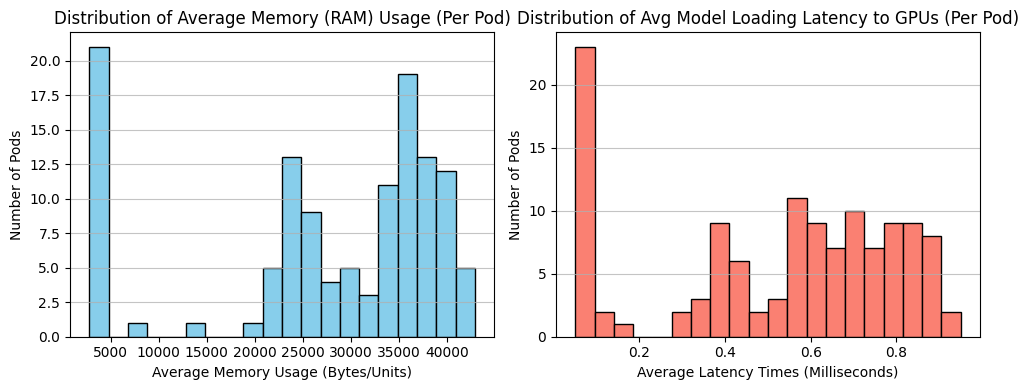

In [4]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4)) 

# Plot 1: Distribution of Average Memory (RAM) Usage
# "basemodel_means" actually contains GPU Byte data
ax1.hist(result_df1["basemodel_update_median"], bins=20, color='skyblue', edgecolor='black')
ax1.set_title('Distribution of Average Memory (RAM) Usage (Per Pod)')
ax1.set_xlabel('Average Memory Usage (Bytes/Units)')
ax1.set_ylabel('Number of Pods')
ax1.grid(axis='y', alpha=0.75)

# Plot 2: Distribution of Average Model Loading Latency
ax2.hist(result_df1["pod_memory_median"], bins=20, color='salmon', edgecolor='black')
ax2.set_title('Distribution of Avg Model Loading Latency to GPUs (Per Pod)') 
ax2.set_xlabel('Average Latency Times (Milliseconds)')
ax2.set_ylabel('Number of Pods')
ax2.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.savefig('pod_memory_analysis_histograms.png')

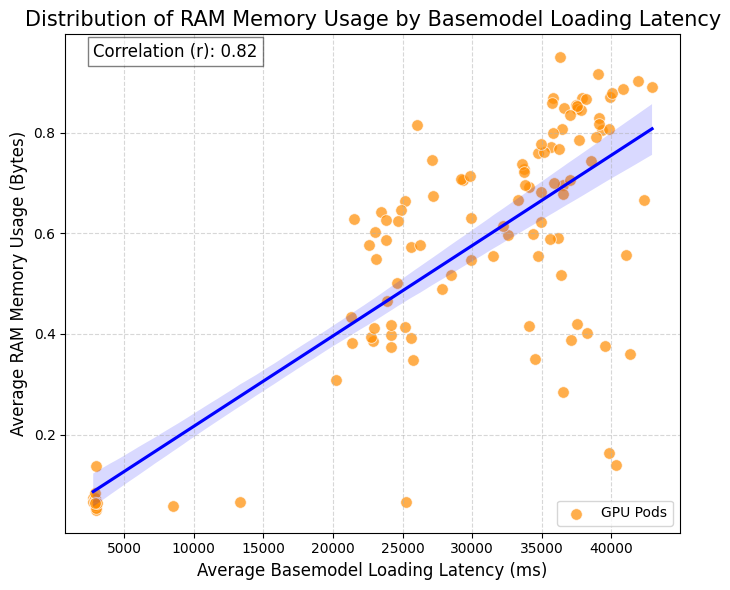

In [5]:
# Median
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 6))

# X: Model Loading Latency to GPU (basemodel_means)
# Y: RAM Memory Usage (pod_memory_means)
sns.scatterplot(data=result_df1, x=result_df1["basemodel_update_median"], y=result_df1["pod_memory_median"], alpha=0.7, s=70, color='darkorange', label='GPU Pods')

# 2. Trend Line (Regression)
sns.regplot(data=result_df1, x=result_df1["basemodel_update_median"], y=result_df1["pod_memory_median"], scatter=False, color='blue', line_kws={"label":"General Trend"})

# Chart Title and Labels
plt.title('Distribution of RAM Memory Usage by Basemodel Loading Latency', fontsize=15)
plt.xlabel('Average Basemodel Loading Latency (ms)', fontsize=12)
plt.ylabel('Average RAM Memory Usage (Bytes)', fontsize=12)

# Improving axis readability
plt.ticklabel_format(style='plain', axis='y') # Plain format for Y-axis (Bytes)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Calculating Correlation Coefficient
correlation = result_df1['basemodel_update_median'].corr(result_df1['pod_memory_median'])
plt.text(result_df1['basemodel_update_median'].min(), result_df1['pod_memory_median'].max(), f'Correlation (r): {correlation:.2f}', 
         fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

plt.tight_layout()
plt.savefig('basemodel_ram_scatter_plot.png')

**`Graph Interpretation:`** As Basemodel Latency increases, RAM usage also increases. This shows that the RAM "sweats" (works heavily) while trying to load the model into the VRAM.
- The bottom-left cluster represents WarmStart pods. The basemodel is already settled in the GPU, and incoming requests go directly to the GPU (WarmStart). The system RAM lies completely empty because it doesn't have to carry massive file weights.
- The clusters in the top-right corner show heavy RAM usage (ColdStart). The system is trying to read the massive basemodel from the disk and move it to the GPU. Because the data cannot be read quickly from the disk, a large amount of data accumulates in the RAM for a long time. As the RAM fills up, the system slows down.
- In the bottom-right corner, model data cannot be transferred properly from the disk to the RAM, or there is an issue transferring it from the RAM to the VRAM. This could be a Network/Timeout issue.

### **<span style="color:orange">2. The base_model loading time of each pod and their GPU consumption </span>**
We are curious about the relationship between the average time it takes for models to be loaded from Disk/Persistent Volumes into GPUs (VRAM) within each container_ip (pod) (basemodel_update_latency_anon.csv) and how much energy/resources the VRAMs consume during this transition process (pod_memory_util_anon.csv). This comparison helps us gain insight into the general processes of the pods within the system. `For example, as the VRAM loading latency increases, the load on the GPU decreases, meaning the GPU is waiting for data. However, being able to make this interpretation does not mean we can make transparent judgments about the pods, such as saying a specific pod is fast, good, or bad. For instance, only a LoRA model might be loaded on a pod at 9 AM, while ControlNet models might be loaded at 10 PM (22:00).

In [6]:
import pandas as pd

averages = {"pod_gpu_memory_median": [], "basemodel_update_median": []}

def function(var1, var2):
    var1_med = var1.groupby("container_ip")["value"].median().reset_index()
    var2_med = var2.groupby("container_ip")["value"].median().reset_index()
    pivot_df = pd.merge(var1_med, var2_med, on="container_ip", how="inner")
    
    pod_gpu_mem_filtered = var1[var1["container_ip"].isin(pivot_df)] 
    basemodel_filtered = var2[var2["container_ip"].isin(pivot_df)]   
    
    for val in pivot_df:
        gpu = pod_gpu_mem_filtered.query("container_ip == @val")
        pipe = basemodel_filtered.query("container_ip == @val")
        
        median_gpu = gpu["value"].median()
        median_base = pipe["value"].median()
        
        averages["pod_gpu_memory_median"].append(median_gpu)
        averages["basemodel_update_median"].append(median_base) 
    
    pivot_df.columns = ["container_ip", "pod_gpu_memory_median", "basemodel_update_median"]
    return pivot_df
    
result = function(dataframes["pod_gpu_memory_used_bytes_anon.csv"], dataframes["basemodel_update_latency_anon.csv"])
print("Table Size:", result.shape) 

display(result.head()) 

max_latency = result["basemodel_update_median"].max()
extreme_point = result[result["basemodel_update_median"] == max_latency].sort_values("pod_gpu_memory_median").head(1)

Table Size: (123, 3)


,container_ip,pod_gpu_memory_median,basemodel_update_median
0,00800b6d2cabe5b9ce855ec9eab6e9ff,2.588541e+10,37919.0
1,03dc060838ef05053bdea6d483cde7e5,3.053663e+10,2843.5
2,05d1c1aea3ae65f6666bb406277c202b,2.495707e+10,34109.0
3,07ff74bdf1b06c02945c40819ec1d38e,3.277219e+10,2898.5
4,081177dd05d758b23a62391e75a1bb34,2.216289e+10,38223.0


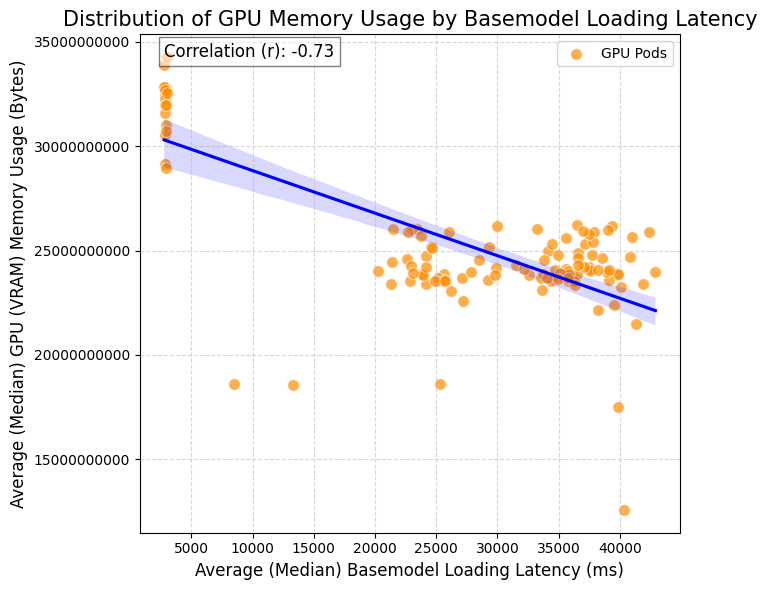

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 6))

# X: Model Loading Latency (basemodel_means)
# Y: GPU Memory Usage (pod_memory_means)
sns.scatterplot(data=result, x=result["basemodel_update_median"], y=result["pod_gpu_memory_median"], alpha=0.7, s=70, color='darkorange', label='GPU Pods')

# 2. Trend Line (Regression)
sns.regplot(data=result, x=result["basemodel_update_median"], y=result["pod_gpu_memory_median"], scatter=False, color='blue', line_kws={"label":"General Trend"})

# Chart Title and Labels
plt.title('Distribution of GPU Memory Usage by Basemodel Loading Latency', fontsize=15)
plt.xlabel('Average (Median) Basemodel Loading Latency (ms)', fontsize=12)
plt.ylabel('Average (Median) GPU (VRAM) Memory Usage (Bytes)', fontsize=12)

# Improving axis readability
plt.ticklabel_format(style='plain', axis='y') # Plain format for Y-axis (Bytes)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Calculating Correlation Coefficient
correlation = result['basemodel_update_median'].corr(result['pod_gpu_memory_median'])
plt.text(result['basemodel_update_median'].min(), result['pod_gpu_memory_median'].max(), f'Correlation (r): {correlation:.2f}', 
         fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

plt.tight_layout()
plt.savefig('basemodel_gpu_scatter_plot.png')

**`Graph Interpretation:`** As Basemodel Latency increases, VRAM usage decreases. The reason for this is that while a model is loading, especially during a Cold Start, the system is busy moving files from the disk to the main memory (RAM). This process takes a very long time. During that time, because the data has not yet reached the GPU, the VRAM is starved for data (waiting idly) and its usage drops.
- The pods in the top-left corner are WarmStart zones. Heavy models have already settled into the VRAM. Since the VRAM is full, an incoming inference request or a small LoRA change is processed instantly.
- The pods in the middle-right and bottom-right corners are ColdStart pods. These are the difficult "bottleneck" moments when the model is trying to be moved to the GPU, as the weights are being transferred to the VRAM over the data bus (network).

### **<span style="color:orange">3. The loading times of all model components for each pod and their GPU consumption</span>**
We are curious about the relationship between the average (median) time it takes for all components like Base Model + LoRA + ControlNet to be combined and loaded into the GPUs (VRAM) within each type of container (pod) to become ready for inference `(pipeline_update_latency_anon.csv)`, and how much resource the VRAMs consume during this preparation process `(pod_gpu_memory_used_bytes_anon.csv)`. I expect the behaviors in this relationship to be almost identical to the behavior of each pod when its average (median) basemodel is being loaded into the VRAM. The reason for this is that the basemodel is the heaviest model in the entire architecture. As I will state again, this analysis `can help us gain insight into situations like whether a specific pod is fast, good, or bad, providing transparency about the pods.`

In [9]:
import pandas as pd

averages = {"pod_gpu_memory_median": [], "pipeline_update_median": []}

def function(var1, var2):
    var1_med = var1.groupby("container_ip")["value"].median().reset_index()
    var2_med = var2.groupby("container_ip")["value"].median().reset_index()
    pivot_df = pd.merge(var1_med, var2_med, on="container_ip", how="inner")
    
    pod_gpu_mem_filtered = var1[var1["container_ip"].isin(pivot_df)] 
    pipeline_filtered = var2[var2["container_ip"].isin(pivot_df)]   
    
    for val in pivot_df:
        gpu = pod_gpu_mem_filtered.query("container_ip == @val")
        pipe = pipeline_filtered.query("container_ip == @val")
        
        median_gpu = gpu["value"].median()
        median_pipe = pipe["value"].median()
        
        averages["pod_gpu_memory_median"].append(median_gpu)
        averages["pipeline_update_median"].append(median_pipe) 
    
    pivot_df.columns = ["container_ip", "pod_gpu_memory_median", "pipeline_update_median"]
    return pivot_df
    
result = function(dataframes["pod_gpu_memory_used_bytes_anon.csv"], dataframes["pipeline_update_latency_anon.csv"])
print("Table Size:", result.shape) 

display(result.head()) 

max_latency = result["pipeline_update_median"].max()
extreme_point = result[result["pipeline_update_median"] == max_latency].sort_values("pod_gpu_memory_median").head(1)

Table Size: (132, 3)


,container_ip,pod_gpu_memory_median,pipeline_update_median
0,00800b6d2cabe5b9ce855ec9eab6e9ff,2.588541e+10,9582.0
1,03dc060838ef05053bdea6d483cde7e5,3.053663e+10,3401.0
2,05d1c1aea3ae65f6666bb406277c202b,2.495707e+10,8974.0
3,07ff74bdf1b06c02945c40819ec1d38e,3.277219e+10,3410.0
4,081177dd05d758b23a62391e75a1bb34,2.216289e+10,10760.0


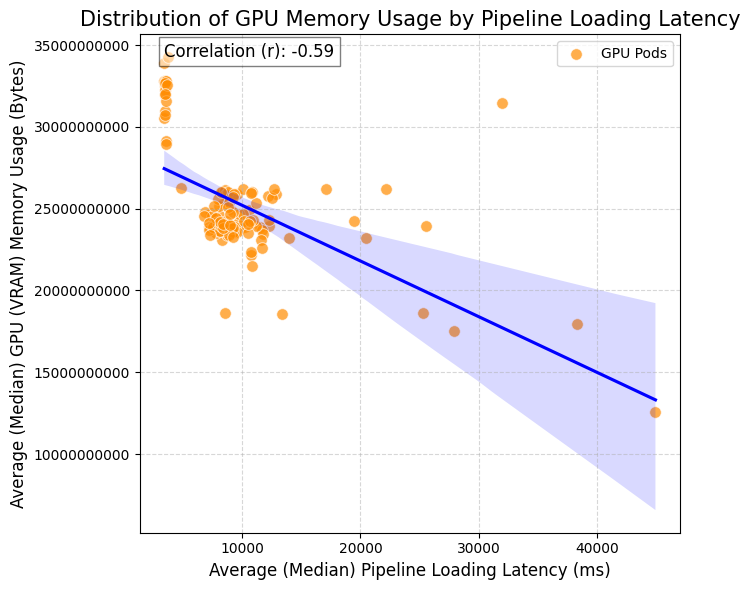

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 6))

# X: Pipeline Loading Latency (pipeline_update_latency)
# Y: GPU Memory Usage (pod_memory_means)
sns.scatterplot(data=result, x=result["pipeline_update_median"], y=result["pod_gpu_memory_median"], alpha=0.7, s=70, color='darkorange', label='GPU Pods')

# 2. Trend Line (Regression)
sns.regplot(data=result, x=result["pipeline_update_median"], y=result["pod_gpu_memory_median"], scatter=False, color='blue', line_kws={"label":"General Trend"})

# Chart Title and Labels
plt.title('Distribution of GPU Memory Usage by Pipeline Loading Latency', fontsize=15)
plt.xlabel('Average (Median) Pipeline Loading Latency (ms)', fontsize=12)
plt.ylabel('Average (Median) GPU (VRAM) Memory Usage (Bytes)', fontsize=12)

# Improving axis readability
plt.ticklabel_format(style='plain', axis='y') # Plain format for Y-axis (Bytes)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Calculating Correlation Coefficient
correlation = result['pipeline_update_median'].corr(result['pod_gpu_memory_median'])
plt.text(result['pipeline_update_median'].min(), result['pod_gpu_memory_median'].max(), f'Correlation (r): {correlation:.2f}', 
         fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

plt.tight_layout()
plt.savefig('pipeline_gpu_scatter_plot.png')

**`Graph Interpretation:`** Regarding the clustered area: Once a pod loads the models into VRAM, they are kept ready in the cache. Since the system does not have to load them from the disk or RAM again, the latency is low. However, this is not the case for the scattered pods.
- For the pod in the bottom-right corner, the latency is quite high because it had to load the models into RAM first, and the VRAM usage is low (ColdStart). It will probably run a specific request on that pod for the first time. The pod in the top-right corner seems to be experiencing both a ColdStart and a heavy processing load simultaneously.
- For the pods in the top-left corner, the pipeline (architecture) is already residing in the VRAM, and inference can be performed immediately in response to incoming requests.